In [3]:
import os

os.environ["QUANDELA_CLOUD_TOKEN"] = "_T_eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJpZCI6MjI0MSwiZXhwIjoxNzg1NzM5MjY2LjYyMjkyMDN9.ZdSxfp1hLOvT2D3nH8r71X7xhOBkgDwt-Tx4181i9WyB39-rDeyVLserD6KIFjN1B9kbX3rgngVCwaupKjdH8g"
os.environ["QUANDELA_PLATFORM"] = "qpu:belenos"

Iris QNN | 1 MZI layers | Perceval 1.1.0 + Merlin
Modes: 8
Input features: 4
Trainable quantum parameters: 14
Trainable prefixes: ['w1_', 'inter1_']

[QPU mode] Training from qpu:belenos BSCount with SPSA
Connected platform: qpu:belenos
Platform status: available
Available commands: ['sample_count', 'samples', 'entropy']
Shots per job: 300
Max shots per call: 300
Min detected photons filter: 1
Quantum parameters: 14
Expected QPU jobs for this run: approximately 42
Every reported QPU metric below is computed from BSCount.
  sample=0 | detected=300 | expectations=[0.2533, 0.07, 0.2133, 0.1033, 0.15, 0.0433, 0.05, 0.1533]
  sample=1 | detected=300 | expectations=[0.2, 0.1733, 0.15, 0.1167, 0.1167, 0.05, 0.2133, 0.0267]
SPSA 01/2 | loss_plus=0.5051 | loss_minus=0.4577 | BSCount_loss=0.3280 | BSCount_acc=1.000 | q_grad_norm=0.492667 | time=360.22s
  sample=0 | detected=300 | expectations=[0.15, 0.25, 0.0433, 0.1233, 0.29, 0.0367, 0.04, 0.1333]
  sample=1 | detected=300 | expectations=[0.213

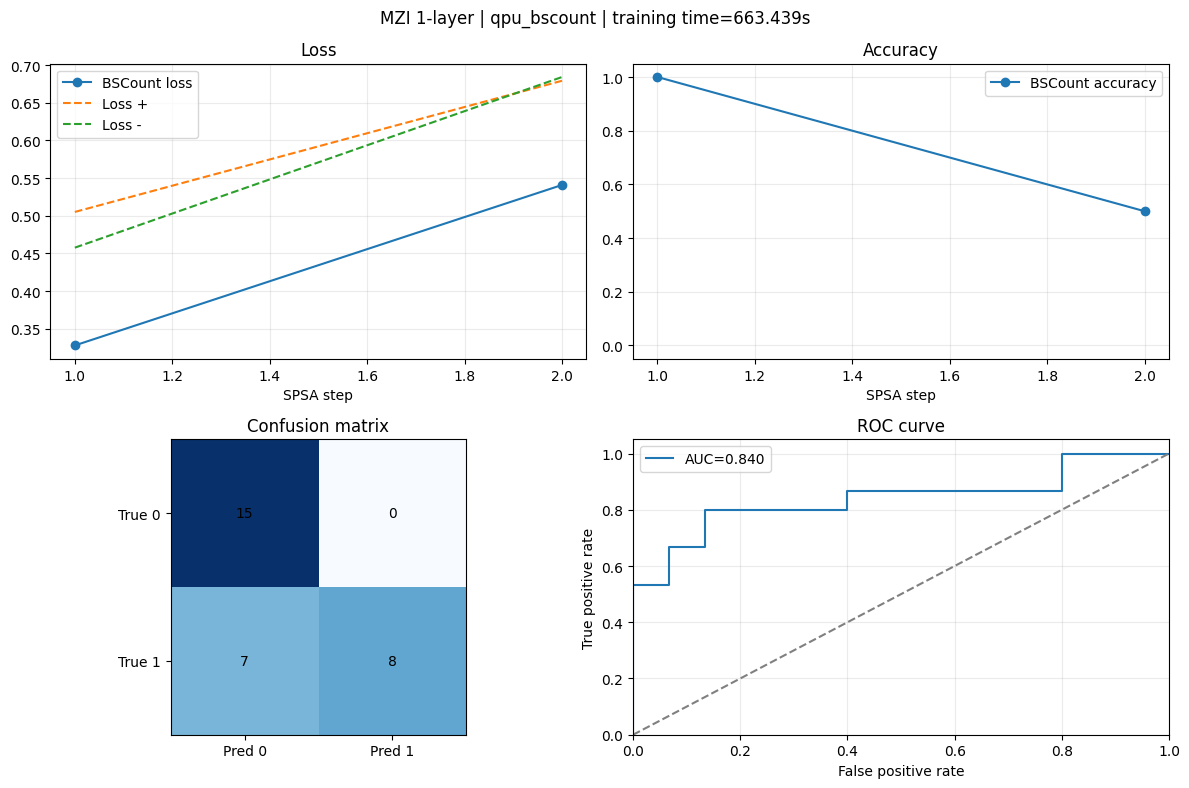

In [6]:
"""Iris QNN with local Merlin training and BSCount-driven Belenos training."""

import json
import math
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import perceval as pcvl
from perceval.algorithm import Sampler
from perceval.components import BS, PS

import merlin as ML

from sklearn.datasets import load_iris as sklearn_load_iris
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Configuration
# ============================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

N_QUBITS = 4
N_MODES = 2 * N_QUBITS
N_FEATURES = 4
N_LAYERS = 1

IRIS_CLASS_0 = 0
IRIS_CLASS_1 = 1
TRAIN_SIZE = 70
TEST_SIZE = 30

LOCAL_EPOCHS = 100
LOCAL_BATCH_SIZE = 4
LOCAL_LR = 0.01

AUTO_PLOT = True
AUTO_SAVE_HISTORY = True
HISTORY_DIRECTORY = r"C:\Quantum"

# False: differentiable local Merlin training.
# True: hardware-in-the-loop SPSA training from qpu:belenos BSCount.
RUN_BELENOS = True
QPU_NAME = os.getenv("QUANDELA_PLATFORM", "qpu:belenos")
QPU_TOKEN = os.getenv("QUANDELA_CLOUD_TOKEN") or None
QPU_SHOTS = 300
QPU_MAX_SHOTS_PER_CALL = QPU_SHOTS
QPU_MIN_DETECTED_PHOTONS = 1
QPU_SPSA_STEPS = 2
QPU_BATCH_SIZE = 2
QPU_TEST_SAMPLES = 30
QPU_CLASSICAL_LR = 0.02

SPSA_A0 = 0.12
SPSA_C0 = 0.18
SPSA_ALPHA = 0.602
SPSA_GAMMA = 0.101
SPSA_STABILITY = 3.0


# ============================================================
# Dataset
# ============================================================

def get_iris_binary_dataset():
    iris = sklearn_load_iris()
    x_all = iris.data.astype(np.float32)
    y_all = iris.target.astype(np.int64)

    mask = (y_all == IRIS_CLASS_0) | (y_all == IRIS_CLASS_1)
    x_all = x_all[mask]
    y_all = (y_all[mask] == IRIS_CLASS_1).astype(np.float32)

    x_train, x_test, y_train, y_test = train_test_split(
        x_all,
        y_all,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_all,
    )

    scaler = MinMaxScaler(feature_range=(0.0, 2.0 * math.pi))
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )


# ============================================================
# Shared photonic circuit
# ============================================================

def build_photonic_qnn():
    slos_processor = pcvl.Processor("SLOS", N_MODES)
    x_params = [pcvl.P(f"x{i}") for i in range(N_FEATURES)]
    trainable_params = []
    trainable_prefixes = []

    # MZI-like encoding makes input phases observable in output statistics.
    for qubit in range(N_QUBITS):
        slos_processor.add(2 * qubit, BS.Ry())
        slos_processor.add(2 * qubit + 1, PS(phi=x_params[qubit]))
        slos_processor.add(2 * qubit, BS.Ry())

    for layer in range(1, N_LAYERS + 1):
        weight_prefix = f"w{layer}_"
        inter_prefix = f"inter{layer}_"
        trainable_prefixes.extend([weight_prefix, inter_prefix])

        weights = [pcvl.P(f"{weight_prefix}{mode}") for mode in range(N_MODES)]
        inter_params = [pcvl.P(f"{inter_prefix}{mode}") for mode in range(1, 7)]
        trainable_params.extend(weights)
        trainable_params.extend(inter_params)

        weight_index = 0
        for qubit in range(N_QUBITS):
            slos_processor.add(2 * qubit, PS(phi=weights[weight_index]))
            weight_index += 1
            slos_processor.add(2 * qubit + 1, PS(phi=weights[weight_index]))
            weight_index += 1
            slos_processor.add(2 * qubit, BS.Ry())

        for start in (1, 3, 5):
            slos_processor.add((start, start + 1), BS.Ry())

        for mode in range(1, 7):
            slos_processor.add(mode, PS(phi=inter_params[mode - 1]))

        for qubit in range(N_QUBITS):
            slos_processor.add(2 * qubit, BS.Ry())

    circuit = slos_processor.linear_circuit()
    return circuit, slos_processor, x_params, trainable_params, trainable_prefixes


class IrisPhotonicQNN(nn.Module):
    def __init__(self, circuit, trainable_prefixes):
        super().__init__()

        measurement = ML.MeasurementStrategy.mode_expectations(
            computation_space=ML.ComputationSpace.UNBUNCHED
        )

        self.q_layer = ML.QuantumLayer(
            input_size=N_FEATURES,
            circuit=circuit,
            input_state=pcvl.BasicState([1, 0] * N_QUBITS),
            n_photons=N_QUBITS,
            input_parameters=["x"],
            trainable_parameters=trainable_prefixes,
            measurement_strategy=measurement,
            dtype=torch.float32,
        )

        self.fc = nn.Sequential(
            nn.LayerNorm(N_MODES),
            nn.Linear(N_MODES, 1),
        )

    def forward(self, x):
        expectations = self.q_layer(x)
        if expectations.dim() == 1:
            expectations = expectations.unsqueeze(0)
        return self.fc(expectations).squeeze(-1)


# ============================================================
# Metrics and local differentiable training
# ============================================================

def metrics_from_logits(logits, targets, criterion):
    loss = criterion(logits, targets)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == targets).float().mean()
    return loss, accuracy, probabilities, predictions


def classification_metrics_from_probabilities(targets, probabilities):
    y_true = targets.detach().cpu().numpy().astype(np.int64)
    y_probability = probabilities.detach().cpu().numpy()
    y_prediction = (y_probability >= 0.5).astype(np.int64)

    matrix = confusion_matrix(y_true, y_prediction, labels=[0, 1])
    precision = precision_score(y_true, y_prediction, zero_division=0)
    recall = recall_score(y_true, y_prediction, zero_division=0)
    roc_auc = (
        roc_auc_score(y_true, y_probability)
        if np.unique(y_true).size == 2
        else float("nan")
    )

    return {
        "confusion_matrix": matrix,
        "precision": float(precision),
        "recall": float(recall),
        "roc_auc": float(roc_auc),
    }


def print_classification_metrics(label, targets, probabilities):
    metrics = classification_metrics_from_probabilities(targets, probabilities)
    matrix = metrics["confusion_matrix"]
    print(f"{label} confusion matrix [[TN, FP], [FN, TP]]: {matrix.tolist()}")
    print(f"{label} precision: {metrics['precision']:.4f}")
    print(f"{label} recall/sensitivity: {metrics['recall']:.4f}")
    print(f"{label} ROC-AUC: {metrics['roc_auc']:.4f}")
    return metrics


def evaluate_local(model, x, y, criterion):
    model.eval()
    with torch.no_grad():
        return metrics_from_logits(model(x), y, criterion)


def train_local(model, x_train, x_test, y_train, y_test):
    loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=LOCAL_BATCH_SIZE,
        shuffle=True,
    )
    optimizer = optim.Adam(model.parameters(), lr=LOCAL_LR)
    criterion = nn.BCEWithLogitsLoss()
    total_start = time.time()

    history = {
        "mode": "local",
        "layers": N_LAYERS,
        "dataset": {
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(len(x_test)),
        },
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "epoch_time_s": [],
    }
    quantum_before = {
        name: parameter.detach().clone()
        for name, parameter in model.q_layer.named_parameters()
    }

    training_start = time.time()
    for epoch in range(1, LOCAL_EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)

        train_loss = total_loss / len(x_train)
        _, train_acc, _, _ = evaluate_local(model, x_train, y_train, criterion)
        test_loss, test_acc, _, _ = evaluate_local(model, x_test, y_test, criterion)
        epoch_time = time.time() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_acc.item()))
        history["test_loss"].append(float(test_loss.item()))
        history["test_accuracy"].append(float(test_acc.item()))
        history["epoch_time_s"].append(float(epoch_time))

        print(
            f"Epoch {epoch:02d}/{LOCAL_EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc.item():.3f} | "
            f"test_loss={test_loss.item():.4f} | test_acc={test_acc.item():.3f} | "
            f"time={epoch_time:.3f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_loss, test_acc, probabilities, predictions = evaluate_local(
        model, x_test, y_test, criterion
    )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = max(
        (parameter.detach() - quantum_before[name]).abs().max().item()
        for name, parameter in model.q_layer.named_parameters()
    )
    classification = print_classification_metrics("Local test", y_test, probabilities)

    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test.tolist(),
    }
    history["quantum_parameter_max_delta"] = float(max_delta)

    print(f"Local training time: {training_time:.3f}s")
    print(f"Local final evaluation time: {evaluation_time:.3f}s")
    print(f"Local total wall time: {total_wall_time:.3f}s")
    print("Quantum parameters updated:", max_delta > 0)
    print("Max |delta quantum parameters|:", max_delta)
    print(f"Final local loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("Probabilities:", probabilities.tolist())
    print("Predictions  :", predictions.tolist())
    print("Labels       :", y_test.tolist())
    return history


# ============================================================
# Merlin parameter storage <-> Perceval parameter names
# ============================================================

def parameter_layout():
    layout = []
    for layer in range(1, N_LAYERS + 1):
        layout.append((f"w{layer}_", N_MODES, 0))
        layout.append((f"inter{layer}_", 6, 1))
    return layout


def flatten_quantum_parameters(model):
    chunks = []
    for prefix, _, _ in parameter_layout():
        chunks.append(getattr(model.q_layer, prefix).detach().flatten())
    return torch.cat(chunks).clone()


def assign_quantum_parameters(model, theta):
    offset = 0
    with torch.no_grad():
        for prefix, size, _ in parameter_layout():
            parameter = getattr(model.q_layer, prefix)
            parameter.copy_(theta[offset : offset + size].view_as(parameter))
            offset += size


def wrap_phases(theta):
    return torch.remainder(theta + math.pi, 2.0 * math.pi) - math.pi


def theta_to_perceval_parameters(theta):
    values = {}
    offset = 0

    for prefix, size, first_index in parameter_layout():
        for local_index in range(size):
            values[f"{prefix}{local_index + first_index}"] = float(
                theta[offset + local_index]
            )
        offset += size

    return values


def input_to_perceval_parameters(x):
    return {f"x{index}": float(x[index]) for index in range(N_FEATURES)}


# ============================================================
# Belenos BSCount execution and expectation values
# ============================================================

def bscount_to_mode_expectations(counts):
    """Convert BSCount to Merlin UNBUNCHED mode expectation values."""
    total_count = float(sum(counts.values()))
    if total_count <= 0:
        raise RuntimeError("The QPU returned an empty BSCount result.")

    expectations = torch.zeros(N_MODES, dtype=torch.float32)
    for state, count in counts.items():
        for mode in range(N_MODES):
            # UNBUNCHED expectation = P(mode contains at least one photon).
            expectations[mode] += float(count) * float(state[mode] >= 1)

    return expectations / total_count


class BelenosBSCountRunner:
    def __init__(
        self,
        circuit,
        token,
        shots=QPU_SHOTS,
        max_shots_per_call=QPU_MAX_SHOTS_PER_CALL,
        min_detected_photons=QPU_MIN_DETECTED_PHOTONS,
    ):
        if not token:
            raise RuntimeError(
                "Missing QUANDELA_CLOUD_TOKEN. Set it before enabling RUN_BELENOS."
            )
        if QPU_NAME != "qpu:belenos":
            raise ValueError(
                f"Expected QPU_NAME='qpu:belenos', received {QPU_NAME!r}."
            )

        self.shots = int(shots)
        self.max_shots_per_call = int(max_shots_per_call)
        self.min_detected_photons = int(min_detected_photons)
        self.processor = pcvl.RemoteProcessor(QPU_NAME, token=token)
        self.processor.set_circuit(circuit)
        self.processor.with_input(pcvl.BasicState([1, 0] * N_QUBITS))
        if hasattr(self.processor, "min_detected_photons_filter"):
            self.processor.min_detected_photons_filter(self.min_detected_photons)
        elif hasattr(self.processor, "min_detected_photon_filter"):
            self.processor.min_detected_photon_filter(self.min_detected_photons)
        else:
            raise AttributeError("RemoteProcessor has no min detected photons filter method.")
        self.sampler = Sampler(
            self.processor,
            max_shots_per_call=self.max_shots_per_call,
        )

        print("Connected platform:", self.processor.name)
        print("Platform status:", self.processor.status)
        print("Available commands:", self.processor.available_commands)
        print("Shots per job:", self.shots)
        print("Max shots per call:", self.max_shots_per_call)
        print("Min detected photons filter:", self.min_detected_photons)

    def sample_counts(self, x, theta):
        values = theta_to_perceval_parameters(theta)
        values.update(input_to_perceval_parameters(x))

        circuit_parameters = self.processor.get_circuit_parameters()
        missing = set(values).difference(circuit_parameters)
        if missing:
            raise RuntimeError(f"Circuit parameters not found on QPU: {sorted(missing)}")

        for name, value in values.items():
            circuit_parameters[name].set_value(value)

        result = self.sampler.sample_count.execute_sync(max_samples=self.shots)
        counts = result.get("results")
        if counts is None:
            raise RuntimeError(f"Unexpected QPU result keys: {list(result)}")
        return counts

    def expectation_batch(self, x_batch, theta, verbose=False):
        rows = []
        for sample_index, x in enumerate(x_batch):
            counts = self.sample_counts(x, theta)
            expectations = bscount_to_mode_expectations(counts)
            rows.append(expectations)

            if verbose:
                print(
                    f"  sample={sample_index} | detected={sum(counts.values())} | "
                    f"expectations={[round(v, 4) for v in expectations.tolist()]}"
                )

        return torch.stack(rows)


def balanced_batch_indices(labels, batch_size):
    positive = torch.where(labels >= 0.5)[0]
    negative = torch.where(labels < 0.5)[0]
    half = max(1, batch_size // 2)

    positive_ids = positive[torch.randperm(len(positive))[:half]]
    negative_ids = negative[torch.randperm(len(negative))[:half]]
    indices = torch.cat([positive_ids, negative_ids])

    if len(indices) < batch_size:
        remaining = torch.randperm(len(labels))[: batch_size - len(indices)]
        indices = torch.cat([indices, remaining])

    return indices[:batch_size]


def qpu_loss_and_accuracy(model, expectations, targets, criterion):
    logits = model.fc(expectations).squeeze(-1)
    loss, accuracy, probabilities, predictions = metrics_from_logits(
        logits, targets, criterion
    )
    return loss, accuracy, probabilities, predictions, logits


# ============================================================
# Hardware-in-the-loop SPSA training from BSCount
# ============================================================

def train_on_belenos(model, circuit, x_train, x_test, y_train, y_test):
    total_start = time.time()
    criterion = nn.BCEWithLogitsLoss()
    classical_optimizer = optim.Adam(model.fc.parameters(), lr=QPU_CLASSICAL_LR)
    runner = BelenosBSCountRunner(
        circuit,
        QPU_TOKEN,
        shots=QPU_SHOTS,
        max_shots_per_call=QPU_MAX_SHOTS_PER_CALL,
        min_detected_photons=QPU_MIN_DETECTED_PHOTONS,
    )

    theta = wrap_phases(flatten_quantum_parameters(model))
    assign_quantum_parameters(model, theta)
    theta_before = theta.clone()
    expected_jobs = 3 * QPU_BATCH_SIZE * QPU_SPSA_STEPS + min(
        QPU_TEST_SAMPLES, len(x_test)
    )
    history = {
        "mode": "qpu_bscount",
        "layers": N_LAYERS,
        "dataset": {
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(min(QPU_TEST_SAMPLES, len(x_test))),
        },
        "qpu_name": QPU_NAME,
        "shots_per_job": QPU_SHOTS,
        "max_shots_per_call": QPU_MAX_SHOTS_PER_CALL,
        "min_detected_photons_filter": QPU_MIN_DETECTED_PHOTONS,
        "expected_jobs": int(expected_jobs),
        "step": [],
        "loss_plus": [],
        "loss_minus": [],
        "train_loss": [],
        "train_accuracy": [],
        "quantum_gradient_norm": [],
        "step_time_s": [],
    }

    print(f"Quantum parameters: {theta.numel()}")
    print(f"Expected QPU jobs for this run: approximately {expected_jobs}")
    print("Every reported QPU metric below is computed from BSCount.")

    training_start = time.time()
    for step in range(1, QPU_SPSA_STEPS + 1):
        step_start = time.time()
        ids = balanced_batch_indices(y_train, QPU_BATCH_SIZE)
        xb = x_train[ids]
        yb = y_train[ids]

        ak = SPSA_A0 / ((step + SPSA_STABILITY) ** SPSA_ALPHA)
        ck = SPSA_C0 / (step**SPSA_GAMMA)
        delta = 2.0 * torch.randint(0, 2, theta.shape).float() - 1.0

        theta_plus = wrap_phases(theta + ck * delta)
        theta_minus = wrap_phases(theta - ck * delta)
        plus_expectations = runner.expectation_batch(xb, theta_plus)
        minus_expectations = runner.expectation_batch(xb, theta_minus)

        with torch.no_grad():
            loss_plus = qpu_loss_and_accuracy(
                model, plus_expectations, yb, criterion
            )[0].item()
            loss_minus = qpu_loss_and_accuracy(
                model, minus_expectations, yb, criterion
            )[0].item()

        quantum_gradient = ((loss_plus - loss_minus) / (2.0 * ck)) * delta
        theta = wrap_phases(theta - ak * quantum_gradient)
        assign_quantum_parameters(model, theta)

        updated_expectations = runner.expectation_batch(xb, theta, verbose=True)
        classical_optimizer.zero_grad(set_to_none=True)
        train_loss, _, _, _, _ = qpu_loss_and_accuracy(
            model, updated_expectations, yb, criterion
        )
        train_loss.backward()
        classical_optimizer.step()

        with torch.no_grad():
            train_loss, train_acc, probabilities, predictions, _ = qpu_loss_and_accuracy(
                model, updated_expectations, yb, criterion
            )

        step_time = time.time() - step_start
        history["step"].append(step)
        history["loss_plus"].append(float(loss_plus))
        history["loss_minus"].append(float(loss_minus))
        history["train_loss"].append(float(train_loss.item()))
        history["train_accuracy"].append(float(train_acc.item()))
        history["quantum_gradient_norm"].append(float(quantum_gradient.norm().item()))
        history["step_time_s"].append(float(step_time))

        print(
            f"SPSA {step:02d}/{QPU_SPSA_STEPS} | "
            f"loss_plus={loss_plus:.4f} | loss_minus={loss_minus:.4f} | "
            f"BSCount_loss={train_loss.item():.4f} | "
            f"BSCount_acc={train_acc.item():.3f} | "
            f"q_grad_norm={quantum_gradient.norm().item():.6f} | "
            f"time={step_time:.2f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_count = min(QPU_TEST_SAMPLES, len(x_test))
    test_expectations = runner.expectation_batch(
        x_test[:test_count], theta, verbose=True
    )
    with torch.no_grad():
        test_loss, test_acc, probabilities, predictions, _ = qpu_loss_and_accuracy(
            model, test_expectations, y_test[:test_count], criterion
        )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = (theta - theta_before).abs().max().item()
    classification = print_classification_metrics(
        "QPU BSCount test", y_test[:test_count], probabilities
    )
    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test[:test_count].tolist(),
        "mode_expectations": test_expectations.tolist(),
    }
    history["quantum_parameter_max_delta"] = float(max_delta)

    print(f"QPU SPSA training time: {training_time:.3f}s")
    print(f"QPU final evaluation time: {evaluation_time:.3f}s")
    print(f"QPU total wall time: {total_wall_time:.3f}s")
    print("Quantum parameters updated from BSCount:", max_delta > 0)
    print("Max |delta quantum parameters|:", max_delta)
    print(f"Final QPU loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("QPU probabilities:", probabilities.tolist())
    print("QPU predictions  :", predictions.tolist())
    print("QPU labels       :", y_test[:test_count].tolist())
    return history


# ============================================================
# History export and plots
# ============================================================

def save_history_json(history, path=None):
    if path is None:
        path = os.path.join(
            HISTORY_DIRECTORY,
            f"MZI-{N_LAYERS}layers-{history['mode']}-history.json",
        )
    with open(path, "w", encoding="utf-8") as file:
        json.dump(history, file, indent=2, ensure_ascii=False)
    print("History saved to:", path)
    return path


def plot_training_history(history):
    import matplotlib.pyplot as plt
    figure, axes = plt.subplots(2, 2, figsize=(12, 8))
    mode = history["mode"]

    if mode == "local":
        x_axis = history["epoch"]
        axes[0, 0].plot(x_axis, history["train_loss"], label="Train loss")
        axes[0, 0].plot(x_axis, history["test_loss"], label="Test loss")
        axes[0, 1].plot(x_axis, history["train_accuracy"], label="Train accuracy")
        axes[0, 1].plot(x_axis, history["test_accuracy"], label="Test accuracy")
        x_label = "Epoch"
    else:
        x_axis = history["step"]
        axes[0, 0].plot(x_axis, history["train_loss"], marker="o", label="BSCount loss")
        axes[0, 0].plot(x_axis, history["loss_plus"], linestyle="--", label="Loss +")
        axes[0, 0].plot(x_axis, history["loss_minus"], linestyle="--", label="Loss -")
        axes[0, 1].plot(
            x_axis, history["train_accuracy"], marker="o", label="BSCount accuracy"
        )
        x_label = "SPSA step"

    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel(x_label)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel(x_label)
    axes[0, 1].set_ylim(-0.05, 1.05)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    final_test = history["final_test"]
    matrix = np.asarray(final_test["confusion_matrix"])
    axes[1, 0].imshow(matrix, cmap="Blues")
    axes[1, 0].set_title("Confusion matrix")
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_yticks([0, 1])
    axes[1, 0].set_xticklabels(["Pred 0", "Pred 1"])
    axes[1, 0].set_yticklabels(["True 0", "True 1"])
    for row in range(2):
        for column in range(2):
            axes[1, 0].text(column, row, int(matrix[row, column]), ha="center", va="center")

    labels = np.asarray(final_test["labels"], dtype=np.int64)
    probabilities = np.asarray(final_test["probabilities"], dtype=float)
    if np.unique(labels).size == 2:
        false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
        axes[1, 1].plot(
            false_positive_rate,
            true_positive_rate,
            label=f"AUC={final_test['roc_auc']:.3f}",
        )
    axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].set_xlabel("False positive rate")
    axes[1, 1].set_ylabel("True positive rate")
    axes[1, 1].set_title("ROC curve")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.25)

    training_time = history["timing"]["training_time_s"]
    figure.suptitle(
        f"MZI {N_LAYERS}-layer | {mode} | training time={training_time:.3f}s"
    )
    figure.tight_layout()
    plt.show()
    return figure, axes


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 68)
    print(f"Iris QNN | {N_LAYERS} MZI layers | Perceval 1.1.0 + Merlin")
    print("=" * 68)

    x_train, x_test, y_train, y_test = get_iris_binary_dataset()
    circuit, _, x_params, trainable_params, trainable_prefixes = build_photonic_qnn()

    print("Modes:", circuit.m)
    print("Input features:", len(x_params))
    print("Trainable quantum parameters:", len(trainable_params))
    print("Trainable prefixes:", trainable_prefixes)

    model = IrisPhotonicQNN(circuit, trainable_prefixes)

    if RUN_BELENOS:
        print("\n[QPU mode] Training from qpu:belenos BSCount with SPSA")
        history = train_on_belenos(
            model, circuit, x_train, x_test, y_train, y_test
        )
    else:
        print("\n[Local mode] Differentiable Merlin training")
        history = train_local(model, x_train, x_test, y_train, y_test)

    return model, history


if __name__ == "__main__":
    MODEL, HISTORY = main()
    if AUTO_SAVE_HISTORY:
        HISTORY_PATH = save_history_json(HISTORY)
    if AUTO_PLOT:
        FIGURE, AXES = plot_training_history(HISTORY)



QPU BSCount result
------------------
Confusion matrix [[TN, FP], [FN, TP]]:
[[15  0]
 [ 7  8]]
Accuracy  : 0.7667
Precision : 1.0000
Recall    : 0.5333
ROC-AUC   : 0.8400

Local ideal result with same trained parameters
-----------------------------------------------
Confusion matrix [[TN, FP], [FN, TP]]:
[[15  0]
 [ 5 10]]
Accuracy  : 0.8333
Precision : 1.0000
Recall    : 0.6667
ROC-AUC   : 0.7556

Expectation-level QPU deviation
--------------------------------
MAE      : 0.367681
RMSE     : 0.375662
Max abs  : 0.533947
Per-mode MAE:
  mode 0: 0.339390
  mode 1: 0.314870
  mode 2: 0.377690
  mode 3: 0.375496
  mode 4: 0.333752
  mode 5: 0.425409
  mode 6: 0.411506
  mode 7: 0.363331

Probability-level QPU deviation
--------------------------------
MAE              : 0.071578
RMSE             : 0.091488
Max abs          : 0.250838
Prediction flips : 2 / 30

Finite-shot noise check
-----------------------
Shots per QPU call       : 300
Entries compared         : 240
Outside 2 sigma  

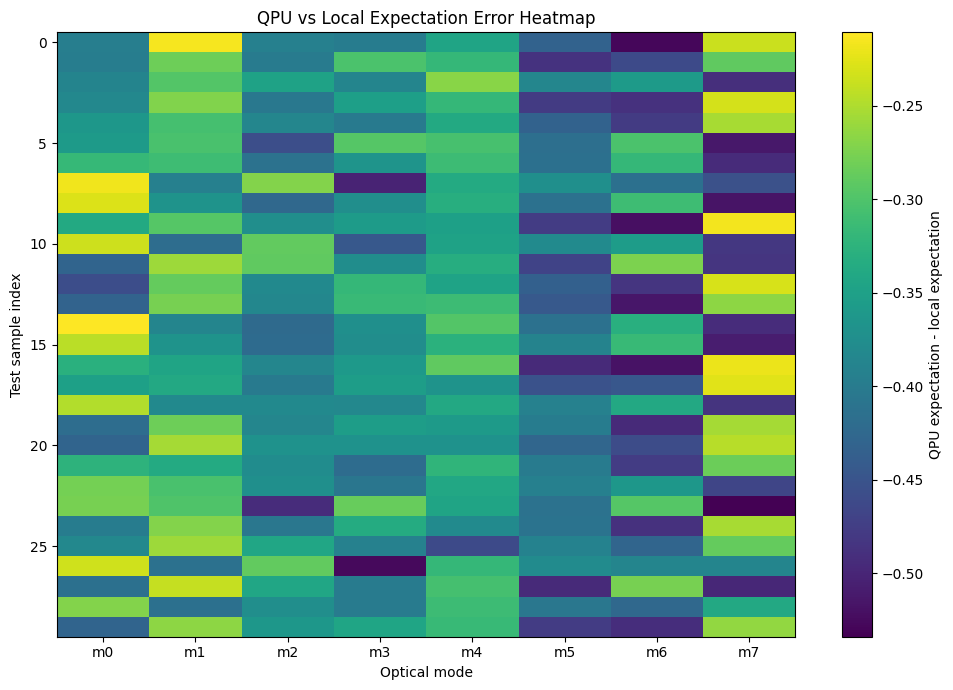

Saved: C:\Quantum\qpu_vs_local_plots\01_expectation_error_heatmap.png


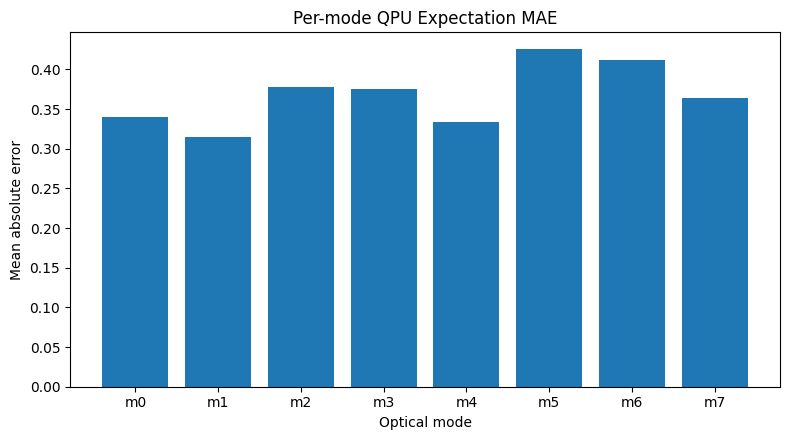

Saved: C:\Quantum\qpu_vs_local_plots\02_per_mode_expectation_mae.png


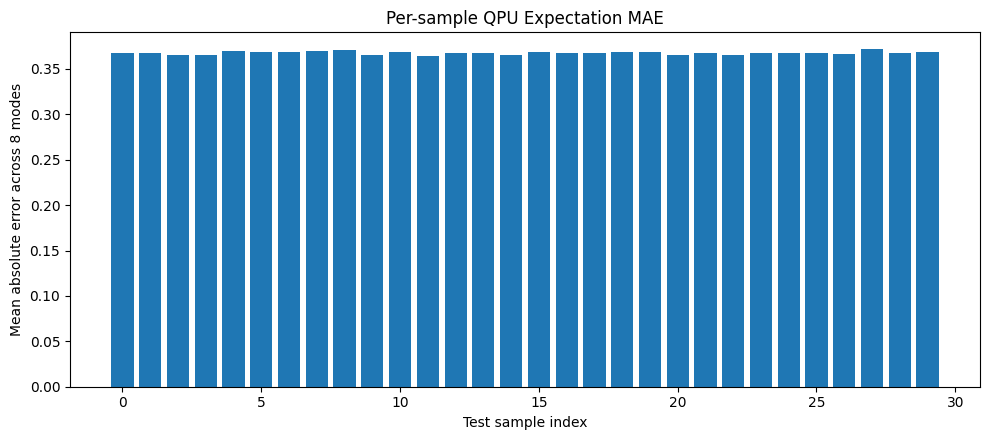

Saved: C:\Quantum\qpu_vs_local_plots\03_per_sample_expectation_mae.png


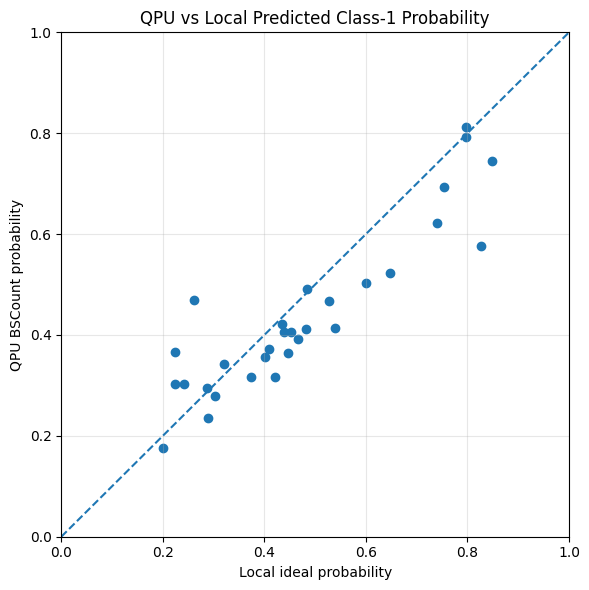

Saved: C:\Quantum\qpu_vs_local_plots\04_qpu_vs_local_probability_scatter.png


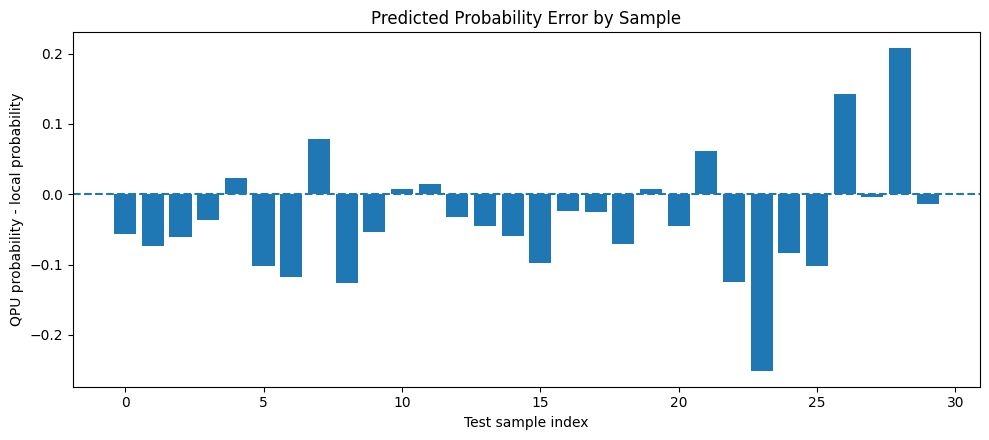

Saved: C:\Quantum\qpu_vs_local_plots\05_probability_error_by_sample.png


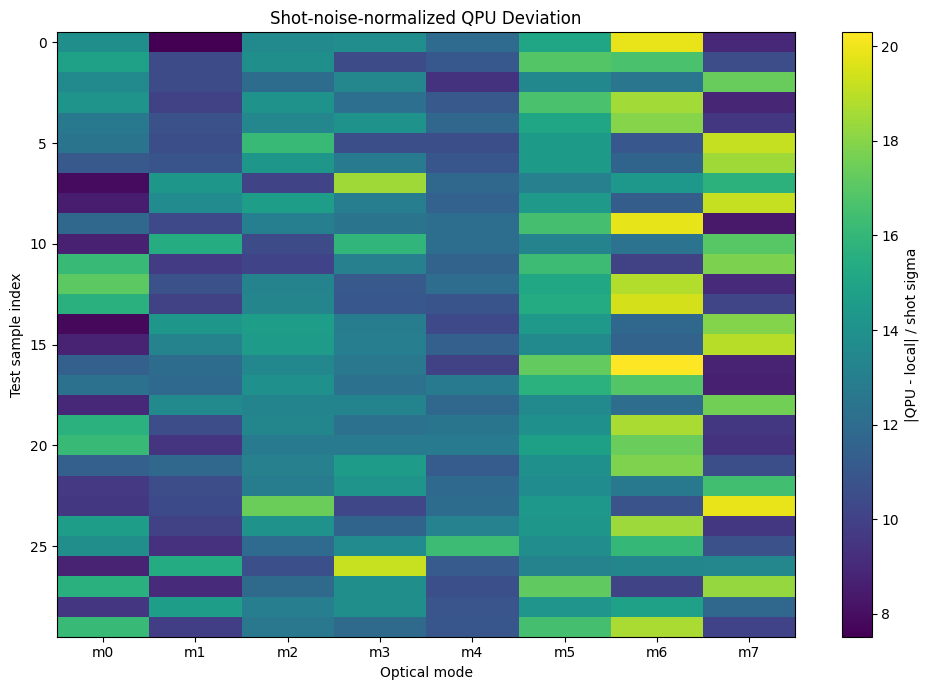

Saved: C:\Quantum\qpu_vs_local_plots\06_z_score_heatmap.png


In [7]:
# ============================================================
# Local ideal vs QPU BSCount error analysis
# Paste this cell AFTER the QPU run has finished.
# It compares:
#   QPU BSCount expectations
#   vs
#   Local ideal Merlin/SLOS expectations
# using the SAME trained model parameters.
# ============================================================

import os
import json
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if HISTORY["mode"] != "qpu_bscount":
    raise RuntimeError(
        "This comparison must be run after a QPU BSCount run. "
        f"Current HISTORY mode is {HISTORY['mode']}."
    )

MODEL.eval()

criterion = nn.BCEWithLogitsLoss()

# Rebuild the same deterministic Iris split
# This works because get_iris_binary_dataset() uses the same SEED.
x_train, x_test, y_train, y_test = get_iris_binary_dataset()

test_count = len(HISTORY["final_test"]["labels"])
x_eval = x_test[:test_count]
y_eval = torch.tensor(
    HISTORY["final_test"]["labels"],
    dtype=torch.float32,
)

qpu_expectations = torch.tensor(
    HISTORY["final_test"]["mode_expectations"],
    dtype=torch.float32,
)

qpu_probabilities = torch.tensor(
    HISTORY["final_test"]["probabilities"],
    dtype=torch.float32,
)

qpu_predictions = torch.tensor(
    HISTORY["final_test"]["predictions"],
    dtype=torch.float32,
)

# ------------------------------------------------------------
# 1. Local ideal expectations from the same trained model
# ------------------------------------------------------------

with torch.no_grad():
    # This uses Merlin local simulator / differentiable quantum layer.
    # It does NOT call qpu:belenos.
    local_expectations = MODEL.q_layer(x_eval)

    if local_expectations.dim() == 1:
        local_expectations = local_expectations.unsqueeze(0)

    local_logits = MODEL.fc(local_expectations).squeeze(-1)
    local_loss = criterion(local_logits, y_eval)
    local_probabilities = torch.sigmoid(local_logits)
    local_predictions = (local_probabilities >= 0.5).float()
    local_accuracy = (local_predictions == y_eval).float().mean()

# Recompute QPU metrics from stored QPU expectations for consistency
with torch.no_grad():
    qpu_logits = MODEL.fc(qpu_expectations).squeeze(-1)
    qpu_loss = criterion(qpu_logits, y_eval)
    qpu_probabilities_recomputed = torch.sigmoid(qpu_logits)
    qpu_predictions_recomputed = (qpu_probabilities_recomputed >= 0.5).float()
    qpu_accuracy = (qpu_predictions_recomputed == y_eval).float().mean()

# ------------------------------------------------------------
# 2. Metric helper
# ------------------------------------------------------------

def classification_report_from_probs(name, labels, probabilities):
    y_true = labels.detach().cpu().numpy().astype(int)
    y_prob = probabilities.detach().cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    if np.unique(y_true).size == 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = float("nan")

    acc = np.mean(y_pred == y_true)

    print(f"\n{name}")
    print("-" * len(name))
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(cm)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    return {
        "confusion_matrix": cm.tolist(),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "roc_auc": float(auc),
        "probabilities": y_prob.tolist(),
        "predictions": y_pred.tolist(),
    }

qpu_report = classification_report_from_probs(
    "QPU BSCount result",
    y_eval,
    qpu_probabilities_recomputed,
)

local_report = classification_report_from_probs(
    "Local ideal result with same trained parameters",
    y_eval,
    local_probabilities,
)

# ------------------------------------------------------------
# 3. Expectation-level QPU error
# ------------------------------------------------------------

expectation_error = qpu_expectations - local_expectations
abs_expectation_error = expectation_error.abs()

expectation_mae = abs_expectation_error.mean().item()
expectation_rmse = torch.sqrt((expectation_error ** 2).mean()).item()
expectation_max_abs = abs_expectation_error.max().item()

per_mode_mae = abs_expectation_error.mean(dim=0)
per_sample_mae = abs_expectation_error.mean(dim=1)

print("\nExpectation-level QPU deviation")
print("--------------------------------")
print(f"MAE      : {expectation_mae:.6f}")
print(f"RMSE     : {expectation_rmse:.6f}")
print(f"Max abs  : {expectation_max_abs:.6f}")
print("Per-mode MAE:")
for mode, value in enumerate(per_mode_mae.tolist()):
    print(f"  mode {mode}: {value:.6f}")

# ------------------------------------------------------------
# 4. Probability-level QPU error
# ------------------------------------------------------------

prob_error = qpu_probabilities_recomputed - local_probabilities
abs_prob_error = prob_error.abs()

prob_mae = abs_prob_error.mean().item()
prob_rmse = torch.sqrt((prob_error ** 2).mean()).item()
prob_max_abs = abs_prob_error.max().item()

prediction_flips = (qpu_predictions_recomputed != local_predictions).sum().item()

print("\nProbability-level QPU deviation")
print("--------------------------------")
print(f"MAE              : {prob_mae:.6f}")
print(f"RMSE             : {prob_rmse:.6f}")
print(f"Max abs          : {prob_max_abs:.6f}")
print(f"Prediction flips : {int(prediction_flips)} / {test_count}")

# ------------------------------------------------------------
# 5. Shot-noise scale estimate
# ------------------------------------------------------------
# For each mode expectation E_m = P(mode m contains >= 1 photon),
# the finite-shot standard error is approximately:
#
#     sigma = sqrt(p(1-p) / N)
#
# This estimates how much deviation can be explained by only 300 shots.

shots = int(HISTORY.get("shots_per_job", QPU_SHOTS))

p = local_expectations.clamp(1e-6, 1.0 - 1e-6)
shot_sigma = torch.sqrt(p * (1.0 - p) / shots)

z_score = abs_expectation_error / shot_sigma
outside_2sigma = z_score > 2.0
outside_3sigma = z_score > 3.0

outside_2sigma_count = outside_2sigma.sum().item()
outside_3sigma_count = outside_3sigma.sum().item()
total_entries = z_score.numel()

print("\nFinite-shot noise check")
print("-----------------------")
print(f"Shots per QPU call       : {shots}")
print(f"Entries compared         : {total_entries}")
print(f"Outside 2 sigma          : {outside_2sigma_count} / {total_entries}")
print(f"Outside 3 sigma          : {outside_3sigma_count} / {total_entries}")
print(f"Mean z-score             : {z_score.mean().item():.4f}")
print(f"Max z-score              : {z_score.max().item():.4f}")

# ------------------------------------------------------------
# 6. Save numerical comparison
# ------------------------------------------------------------

comparison = {
    "test_count": int(test_count),
    "shots_per_qpu_call": int(shots),
    "expectation_error": {
        "mae": float(expectation_mae),
        "rmse": float(expectation_rmse),
        "max_abs": float(expectation_max_abs),
        "per_mode_mae": per_mode_mae.tolist(),
        "per_sample_mae": per_sample_mae.tolist(),
        "qpu_expectations": qpu_expectations.tolist(),
        "local_expectations": local_expectations.tolist(),
        "qpu_minus_local": expectation_error.tolist(),
        "z_score": z_score.tolist(),
        "outside_2sigma_count": int(outside_2sigma_count),
        "outside_3sigma_count": int(outside_3sigma_count),
    },
    "probability_error": {
        "mae": float(prob_mae),
        "rmse": float(prob_rmse),
        "max_abs": float(prob_max_abs),
        "prediction_flips": int(prediction_flips),
        "qpu_probabilities": qpu_probabilities_recomputed.tolist(),
        "local_probabilities": local_probabilities.tolist(),
        "qpu_minus_local": prob_error.tolist(),
    },
    "qpu_report": qpu_report,
    "local_report": local_report,
}

output_dir = HISTORY_DIRECTORY if "HISTORY_DIRECTORY" in globals() else "."
os.makedirs(output_dir, exist_ok=True)

comparison_path = os.path.join(
    output_dir,
    f"MZI-{N_LAYERS}layers-qpu-vs-local-error-analysis.json",
)

with open(comparison_path, "w", encoding="utf-8") as f:
    json.dump(comparison, f, indent=2)

print("\nSaved comparison JSON to:")
print(comparison_path)

# ------------------------------------------------------------
# 7. Plots
# ------------------------------------------------------------

plot_dir = os.path.join(output_dir, "qpu_vs_local_plots")
os.makedirs(plot_dir, exist_ok=True)

# Plot 1: QPU - local expectation error heatmap
plt.figure(figsize=(10, 7))
plt.imshow(expectation_error.detach().cpu().numpy(), aspect="auto")
plt.colorbar(label="QPU expectation - local expectation")
plt.xlabel("Optical mode")
plt.ylabel("Test sample index")
plt.xticks(range(N_MODES), [f"m{i}" for i in range(N_MODES)])
plt.title("QPU vs Local Expectation Error Heatmap")
plt.tight_layout()
path = os.path.join(plot_dir, "01_expectation_error_heatmap.png")
plt.savefig(path, dpi=220)
plt.show()
print("Saved:", path)

# Plot 2: Per-mode MAE
plt.figure(figsize=(8, 4.5))
plt.bar(range(N_MODES), per_mode_mae.detach().cpu().numpy())
plt.xlabel("Optical mode")
plt.ylabel("Mean absolute error")
plt.xticks(range(N_MODES), [f"m{i}" for i in range(N_MODES)])
plt.title("Per-mode QPU Expectation MAE")
plt.tight_layout()
path = os.path.join(plot_dir, "02_per_mode_expectation_mae.png")
plt.savefig(path, dpi=220)
plt.show()
print("Saved:", path)

# Plot 3: Per-sample MAE
plt.figure(figsize=(10, 4.5))
plt.bar(range(test_count), per_sample_mae.detach().cpu().numpy())
plt.xlabel("Test sample index")
plt.ylabel("Mean absolute error across 8 modes")
plt.title("Per-sample QPU Expectation MAE")
plt.tight_layout()
path = os.path.join(plot_dir, "03_per_sample_expectation_mae.png")
plt.savefig(path, dpi=220)
plt.show()
print("Saved:", path)

# Plot 4: QPU probability vs local probability
plt.figure(figsize=(6, 6))
plt.scatter(
    local_probabilities.detach().cpu().numpy(),
    qpu_probabilities_recomputed.detach().cpu().numpy(),
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Local ideal probability")
plt.ylabel("QPU BSCount probability")
plt.title("QPU vs Local Predicted Class-1 Probability")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
path = os.path.join(plot_dir, "04_qpu_vs_local_probability_scatter.png")
plt.savefig(path, dpi=220)
plt.show()
print("Saved:", path)

# Plot 5: Probability error by sample
plt.figure(figsize=(10, 4.5))
plt.bar(range(test_count), prob_error.detach().cpu().numpy())
plt.axhline(0.0, linestyle="--")
plt.xlabel("Test sample index")
plt.ylabel("QPU probability - local probability")
plt.title("Predicted Probability Error by Sample")
plt.tight_layout()
path = os.path.join(plot_dir, "05_probability_error_by_sample.png")
plt.savefig(path, dpi=220)
plt.show()
print("Saved:", path)

# Plot 6: Z-score heatmap
plt.figure(figsize=(10, 7))
plt.imshow(z_score.detach().cpu().numpy(), aspect="auto")
plt.colorbar(label="|QPU - local| / shot sigma")
plt.xlabel("Optical mode")
plt.ylabel("Test sample index")
plt.xticks(range(N_MODES), [f"m{i}" for i in range(N_MODES)])
plt.title("Shot-noise-normalized QPU Deviation")
plt.tight_layout()
path = os.path.join(plot_dir, "06_z_score_heatmap.png")
plt.savefig(path, dpi=220)
plt.show()
print("Saved:", path)

LOCAL-ONLY MZI QNN RUN
Train samples       : 70
Test samples        : 30
Evaluated samples   : 30
Modes               : 8
MZI layers          : 1
Local epochs        : 100
Local batch size    : 4
Local learning rate : 0.01

Circuit information
-------------------
Input features              : 4
Trainable quantum parameters: 14
Trainable prefixes          : ['w1_', 'inter1_']
Epoch 001/100 | train_loss=0.3427 | train_acc=0.986 | test_loss=0.2675 | test_acc=0.867 | time=0.232s
Epoch 002/100 | train_loss=0.1245 | train_acc=0.986 | test_loss=0.1120 | test_acc=0.967 | time=0.150s
Epoch 003/100 | train_loss=0.0669 | train_acc=0.986 | test_loss=0.0689 | test_acc=1.000 | time=0.161s
Epoch 004/100 | train_loss=0.0457 | train_acc=0.986 | test_loss=0.0359 | test_acc=1.000 | time=0.177s
Epoch 005/100 | train_loss=0.0347 | train_acc=1.000 | test_loss=0.0251 | test_acc=1.000 | time=0.177s
Epoch 006/100 | train_loss=0.0231 | train_acc=1.000 | test_loss=0.0179 | test_acc=1.000 | time=0.170s
Epoch 007/

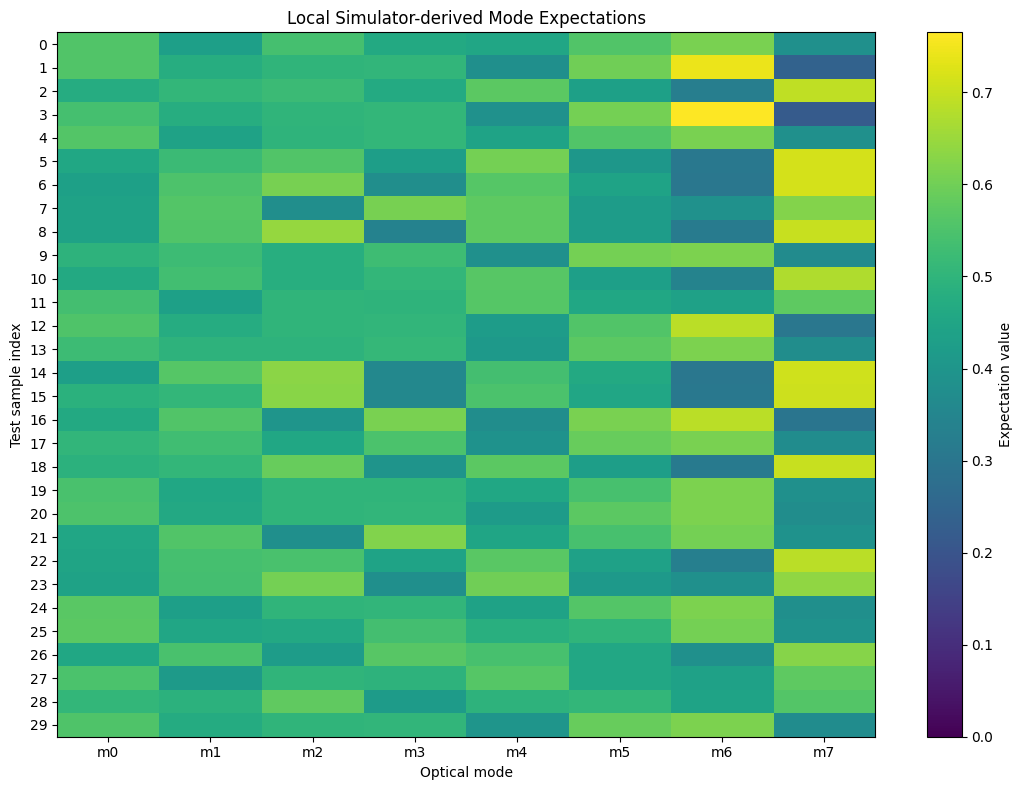

Saved: local_only_mzi_results\01_local_simulator_mode_expectations.png


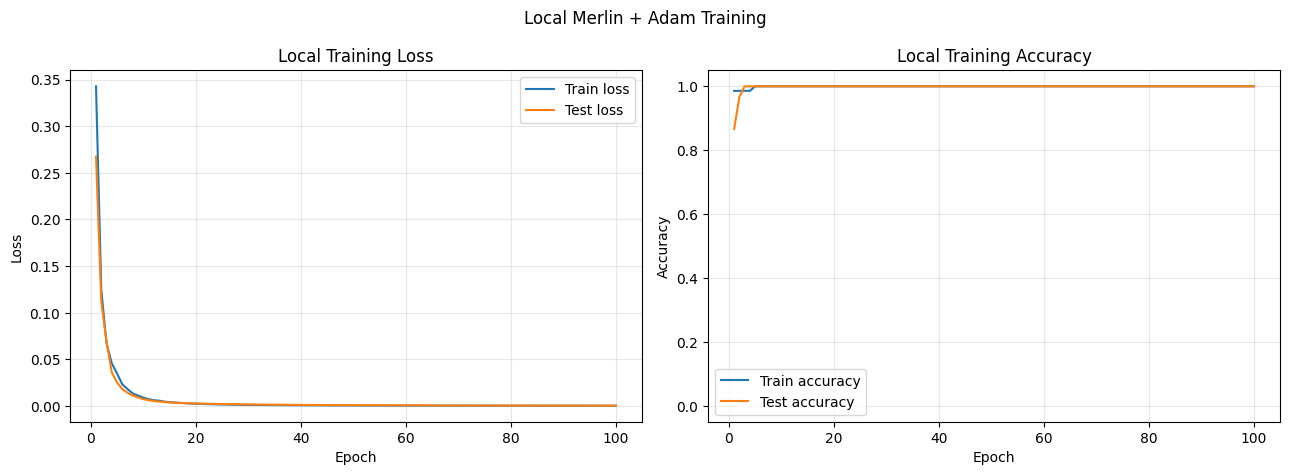

Saved: local_only_mzi_results\02_local_loss_accuracy_curve.png


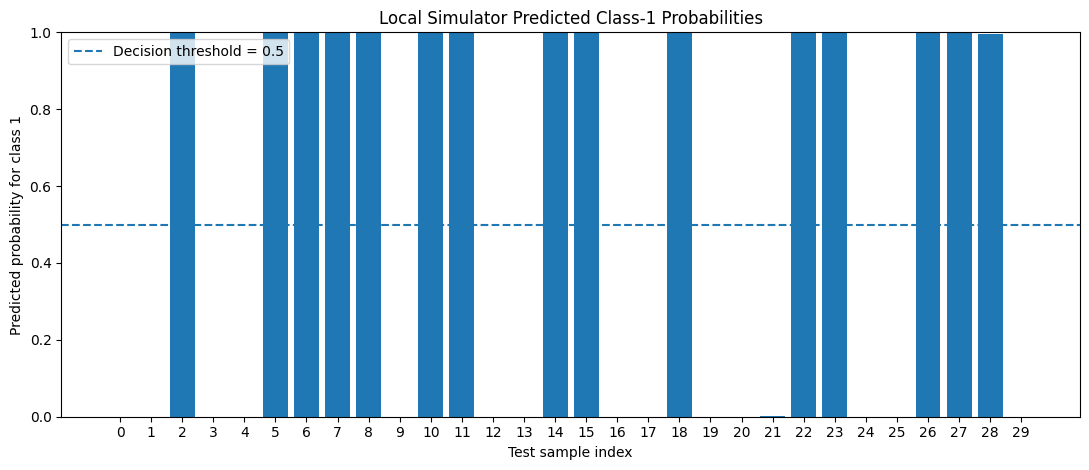

Saved: local_only_mzi_results\03_local_class1_probabilities.png


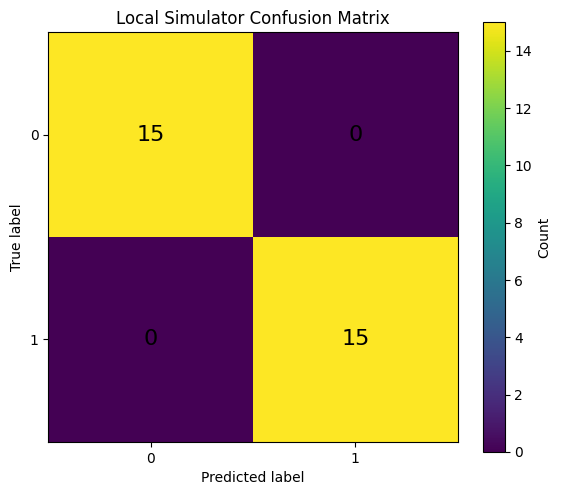

Saved: local_only_mzi_results\04_local_confusion_matrix.png


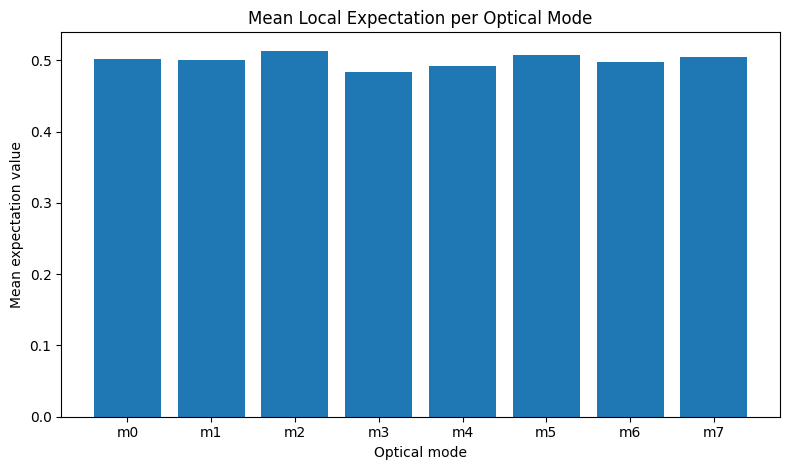

Saved: local_only_mzi_results\05_local_mean_expectation_per_mode.png

Saved numerical local result:
local_only_mzi_results\local_only_mzi_result.json

All local-only plots saved in:
local_only_mzi_results


In [8]:
# ============================================================
# LOCAL-ONLY MZI 1-LAYER PLOTS
# This cell runs the MZI QNN fully locally.
# It does NOT call qpu:belenos.
# It does NOT use BSCount.
#
# Output:
#   1. Local mode expectation heatmap
#   2. Local loss / accuracy curve
#   3. Local class-1 probability plot
#   4. Local confusion matrix
#   5. Local mean expectation per mode
#   6. JSON file with local results
# ============================================================

import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ------------------------------------------------------------
# 0. Safety check
# ------------------------------------------------------------

required_objects = [
    "get_iris_binary_dataset",
    "build_photonic_qnn",
    "IrisPhotonicQNN",
    "N_MODES",
    "N_LAYERS",
    "LOCAL_BATCH_SIZE",
    "LOCAL_LR",
    "LOCAL_EPOCHS",
]

missing = [name for name in required_objects if name not in globals()]

if missing:
    raise RuntimeError(
        "You must run the main definition cells in MZI-1layer.ipynb first. "
        f"Missing objects: {missing}"
    )

# ------------------------------------------------------------
# 1. Local-only configuration
# ------------------------------------------------------------

LOCAL_ONLY_EPOCHS = 100
LOCAL_ONLY_BATCH_SIZE = LOCAL_BATCH_SIZE
LOCAL_ONLY_LR = LOCAL_LR
LOCAL_ONLY_TEST_SAMPLES = 30

LOCAL_ONLY_DIR = "local_only_mzi_results"
os.makedirs(LOCAL_ONLY_DIR, exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------

x_train, x_test, y_train, y_test = get_iris_binary_dataset()

test_count = min(LOCAL_ONLY_TEST_SAMPLES, len(x_test))

x_eval = x_test[:test_count]
y_eval = y_test[:test_count].float()

print("=" * 70)
print("LOCAL-ONLY MZI QNN RUN")
print("=" * 70)
print(f"Train samples       : {len(x_train)}")
print(f"Test samples        : {len(x_test)}")
print(f"Evaluated samples   : {test_count}")
print(f"Modes               : {N_MODES}")
print(f"MZI layers          : {N_LAYERS}")
print(f"Local epochs        : {LOCAL_ONLY_EPOCHS}")
print(f"Local batch size    : {LOCAL_ONLY_BATCH_SIZE}")
print(f"Local learning rate : {LOCAL_ONLY_LR}")

# ------------------------------------------------------------
# 3. Build local MZI model
# ------------------------------------------------------------

circuit, _, x_params, trainable_params, trainable_prefixes = build_photonic_qnn()

local_model = IrisPhotonicQNN(circuit, trainable_prefixes)

print("\nCircuit information")
print("-------------------")
print(f"Input features              : {len(x_params)}")
print(f"Trainable quantum parameters: {len(trainable_params)}")
print(f"Trainable prefixes          : {trainable_prefixes}")

# ------------------------------------------------------------
# 4. Local training with Adam
# ------------------------------------------------------------

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(local_model.parameters(), lr=LOCAL_ONLY_LR)

loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=LOCAL_ONLY_BATCH_SIZE,
    shuffle=True,
)

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
    "epoch_time_s": [],
}

start_time = time.time()

for epoch in range(1, LOCAL_ONLY_EPOCHS + 1):
    epoch_start = time.time()
    local_model.train()

    total_loss = 0.0

    for xb, yb in loader:
        optimizer.zero_grad(set_to_none=True)

        logits = local_model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)

    train_loss = total_loss / len(x_train)

    local_model.eval()
    with torch.no_grad():
        train_logits = local_model(x_train)
        train_probs = torch.sigmoid(train_logits)
        train_preds = (train_probs >= 0.5).float()
        train_acc = (train_preds == y_train).float().mean()

        test_logits = local_model(x_test)
        test_loss = criterion(test_logits, y_test)
        test_probs = torch.sigmoid(test_logits)
        test_preds = (test_probs >= 0.5).float()
        test_acc = (test_preds == y_test).float().mean()

    epoch_time = time.time() - epoch_start

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["train_accuracy"].append(float(train_acc.item()))
    history["test_loss"].append(float(test_loss.item()))
    history["test_accuracy"].append(float(test_acc.item()))
    history["epoch_time_s"].append(float(epoch_time))

    print(
        f"Epoch {epoch:03d}/{LOCAL_ONLY_EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc.item():.3f} | "
        f"test_loss={test_loss.item():.4f} | test_acc={test_acc.item():.3f} | "
        f"time={epoch_time:.3f}s"
    )

total_time = time.time() - start_time

# ------------------------------------------------------------
# 5. Local mode expectations for the first 30 test samples
# ------------------------------------------------------------

local_model.eval()

with torch.no_grad():
    # This is the local equivalent of QPU BSCount-derived expectations.
    # QPU version:
    #     BSCount -> mode expectations
    #
    # Local version:
    #     Merlin local simulator -> mode expectations
    local_expectations = local_model.q_layer(x_eval)

    if local_expectations.dim() == 1:
        local_expectations = local_expectations.unsqueeze(0)

    local_logits = local_model.fc(local_expectations).squeeze(-1)
    local_loss = criterion(local_logits, y_eval)

    local_probabilities = torch.sigmoid(local_logits)
    local_predictions = (local_probabilities >= 0.5).float()
    local_accuracy = (local_predictions == y_eval).float().mean()

# Convert to numpy
local_expectations_np = local_expectations.detach().cpu().numpy()
local_probabilities_np = local_probabilities.detach().cpu().numpy()
local_predictions_np = local_predictions.detach().cpu().numpy().astype(int)
local_labels_np = y_eval.detach().cpu().numpy().astype(int)

# ------------------------------------------------------------
# 6. Local classification metrics
# ------------------------------------------------------------

cm = confusion_matrix(
    local_labels_np,
    local_predictions_np,
    labels=[0, 1],
)

precision = precision_score(
    local_labels_np,
    local_predictions_np,
    zero_division=0,
)

recall = recall_score(
    local_labels_np,
    local_predictions_np,
    zero_division=0,
)

if np.unique(local_labels_np).size == 2:
    roc_auc = roc_auc_score(local_labels_np, local_probabilities_np)
else:
    roc_auc = float("nan")

print("\n" + "=" * 70)
print("LOCAL-ONLY FINAL RESULT ON 30 TEST SAMPLES")
print("=" * 70)
print(f"Local loss        : {local_loss.item():.4f}")
print(f"Local accuracy    : {local_accuracy.item():.4f}")
print(f"Local precision   : {precision:.4f}")
print(f"Local recall      : {recall:.4f}")
print(f"Local ROC-AUC     : {roc_auc:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print("Local probabilities:")
print(local_probabilities_np.tolist())
print("Local predictions:")
print(local_predictions_np.tolist())
print("Local labels:")
print(local_labels_np.tolist())
print(f"Total local wall time: {total_time:.3f}s")

# ------------------------------------------------------------
# 7. Plot 1: Local mode expectation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

plt.imshow(
    local_expectations_np,
    aspect="auto",
    vmin=0.0,
    vmax=max(0.32, float(local_expectations_np.max())),
)

plt.colorbar(label="Expectation value")
plt.xlabel("Optical mode")
plt.ylabel("Test sample index")
plt.xticks(
    range(local_expectations_np.shape[1]),
    [f"m{i}" for i in range(local_expectations_np.shape[1])],
)
plt.yticks(
    range(test_count),
    [str(i) for i in range(test_count)],
)
plt.title("Local Simulator-derived Mode Expectations")

plt.tight_layout()
path_heatmap = os.path.join(
    LOCAL_ONLY_DIR,
    "01_local_simulator_mode_expectations.png",
)
plt.savefig(path_heatmap, dpi=220)
plt.show()

print("Saved:", path_heatmap)

# ------------------------------------------------------------
# 8. Plot 2: Local train/test loss and accuracy
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history["epoch"], history["train_loss"], label="Train loss")
axes[0].plot(history["epoch"], history["test_loss"], label="Test loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Local Training Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history["epoch"], history["train_accuracy"], label="Train accuracy")
axes[1].plot(history["epoch"], history["test_accuracy"], label="Test accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Local Training Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle("Local Merlin + Adam Training")
fig.tight_layout()

path_curve = os.path.join(
    LOCAL_ONLY_DIR,
    "02_local_loss_accuracy_curve.png",
)
plt.savefig(path_curve, dpi=220)
plt.show()

print("Saved:", path_curve)

# ------------------------------------------------------------
# 9. Plot 3: Local predicted class-1 probabilities
# ------------------------------------------------------------

plt.figure(figsize=(11, 4.8))

plt.bar(range(test_count), local_probabilities_np)
plt.axhline(0.5, linestyle="--", label="Decision threshold = 0.5")

plt.xlabel("Test sample index")
plt.ylabel("Predicted probability for class 1")
plt.title("Local Simulator Predicted Class-1 Probabilities")
plt.ylim(0.0, 1.0)
plt.xticks(range(test_count))
plt.legend()

plt.tight_layout()
path_prob = os.path.join(
    LOCAL_ONLY_DIR,
    "03_local_class1_probabilities.png",
)
plt.savefig(path_prob, dpi=220)
plt.show()

print("Saved:", path_prob)

# ------------------------------------------------------------
# 10. Plot 4: Local confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(5.8, 5.0))

plt.imshow(cm)
plt.colorbar(label="Count")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["0", "1"])
plt.yticks([0, 1], ["0", "1"])
plt.title("Local Simulator Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=16,
        )

plt.tight_layout()
path_cm = os.path.join(
    LOCAL_ONLY_DIR,
    "04_local_confusion_matrix.png",
)
plt.savefig(path_cm, dpi=220)
plt.show()

print("Saved:", path_cm)

# ------------------------------------------------------------
# 11. Plot 5: Mean local expectation per optical mode
# ------------------------------------------------------------

per_mode_mean = local_expectations_np.mean(axis=0)

plt.figure(figsize=(8, 4.8))

plt.bar(range(local_expectations_np.shape[1]), per_mode_mean)

plt.xlabel("Optical mode")
plt.ylabel("Mean expectation value")
plt.xticks(
    range(local_expectations_np.shape[1]),
    [f"m{i}" for i in range(local_expectations_np.shape[1])],
)
plt.title("Mean Local Expectation per Optical Mode")

plt.tight_layout()
path_mode_mean = os.path.join(
    LOCAL_ONLY_DIR,
    "05_local_mean_expectation_per_mode.png",
)
plt.savefig(path_mode_mean, dpi=220)
plt.show()

print("Saved:", path_mode_mean)

# ------------------------------------------------------------
# 12. Save local numerical result
# ------------------------------------------------------------

local_result = {
    "mode": "local_only",
    "layers": int(N_LAYERS),
    "test_count": int(test_count),
    "local_epochs": int(LOCAL_ONLY_EPOCHS),
    "local_batch_size": int(LOCAL_ONLY_BATCH_SIZE),
    "local_lr": float(LOCAL_ONLY_LR),
    "local_loss": float(local_loss.item()),
    "local_accuracy": float(local_accuracy.item()),
    "local_precision": float(precision),
    "local_recall": float(recall),
    "local_roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "local_expectations": local_expectations_np.tolist(),
    "local_probabilities": local_probabilities_np.tolist(),
    "local_predictions": local_predictions_np.tolist(),
    "local_labels": local_labels_np.tolist(),
    "training_history": history,
    "total_local_wall_time_s": float(total_time),
    "saved_plots": {
        "mode_expectation_heatmap": path_heatmap,
        "loss_accuracy_curve": path_curve,
        "class1_probabilities": path_prob,
        "confusion_matrix": path_cm,
        "mean_expectation_per_mode": path_mode_mean,
    },
}

json_path = os.path.join(
    LOCAL_ONLY_DIR,
    "local_only_mzi_result.json",
)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(local_result, f, indent=2)

print("\nSaved numerical local result:")
print(json_path)
print("\nAll local-only plots saved in:")
print(LOCAL_ONLY_DIR)